## Library Imports

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, RepeatVector, TimeDistributed, Dense, Dropout

from tensorflow.keras.layers import Input, Bidirectional, Dense, LSTM, RepeatVector, TimeDistributed, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, LSTM, Dense, Dropout, BatchNormalization, RepeatVector

import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Union, Optional
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


from pathlib import Path
import joblib
import os

from typing import List, Tuple, Dict, Union, Optional

.

## Data Preparation

This section of the code is responsible for preparing the data for training, validation, and testing. It splits the dataset into appropriate subsets, normalizes the feature columns, and generates sequences of time series data for model training.

In [7]:
# Function for data preparation
def prepare_data(merged_df, feature_columns):
    # Split data into train and test sets based on 'train_test' column
    train_data = merged_df[merged_df['train_test'] == 'train']
    test_data = merged_df[merged_df['train_test'] == 'prediction']

    # Keep only normal data (status_type_id is 0 or 2) for training
    normal_train_data = train_data[train_data['status_type_id'].isin([0, 2])]

    # Define validation ratio (e.g., 20%)
    val_ratio = 0.2
    split_index = int(len(normal_train_data) * (1 - val_ratio))

    # Sequential split (no shuffle)
    train_data, val_data = normal_train_data.iloc[:split_index], normal_train_data.iloc[split_index:]

    # Normalize the data using StandardScaler
    scaler = StandardScaler()
    normal_train_scaled = scaler.fit_transform(train_data[feature_columns])
    val_scaled = scaler.transform(val_data[feature_columns])
    test_scaled = scaler.transform(test_data[feature_columns])

    return normal_train_scaled, val_scaled, test_scaled, val_data, test_data, feature_columns, scaler


# Function to generate sequences for time series data
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences)

## Model Building

This part of the code defines a CNN-LSTM Autoencoder model, which combines convolutional layers (CNN) and recurrent layers (LSTM) for time series data compression and reconstruction.

- build_cnn_lstm_autoencoder function: Builds a CNN + LSTM Autoencoder model. The encoder consists of convolutional layers followed by LSTM layers, while the decoder uses LSTM layers followed by a convolutional layer for reconstruction.

 - The model is designed to handle time series data, where the convolutional layers extract local features, and the LSTM layers capture long-term dependencies.

  - The model is compiled with the Adam optimizer and mean squared error (MSE) loss function, suitable for reconstruction tasks.

.

In [27]:
# Function to build the CNN + LSTM Autoencoder model
def build_cnn_lstm_autoencoder(input_dim, seq_length, encoding_dim=16):
    # Input layer for sequence data
    inputs = Input(shape=(seq_length, input_dim))

    # CNN Encoder
    x = Conv1D(filters=32, kernel_size=3, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)

    # LSTM Encoder
    x = LSTM(64, activation='relu', return_sequences=True)(x)
    x = LSTM(32, activation='relu', return_sequences=False)(x)
    encoded = Dense(encoding_dim, activation='relu')(x)

    # Decoder
    x = RepeatVector(seq_length)(encoded)
    x = LSTM(32, activation='relu', return_sequences=True)(x)
    x = LSTM(64, activation='relu', return_sequences=True)(x)
    x = Conv1D(filters=input_dim, kernel_size=3, padding='same')(x)

    # Define the model
    model = Model(inputs, x)
    # Compile the model with Adam optimizer and mean squared error loss
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    return model

## Model Training: Fitting and Early Stopping

This part of the code handles model training, including fitting the model to training data, validating it on a validation set, and implementing early stopping to avoid overfitting.

train_model function: Trains the model using the provided training sequences and validation sequences.

 - The early stopping callback monitors the validation loss (val_loss). If the validation loss doesn't improve for 5 consecutive epochs, training is stopped early, and the best model weights are restored to avoid overfitting.

- The fit function trains the model for a given number of epochs and batch size, while also validating the model at each epoch.

- Autoencoder setup: In this case, the input and target are the same, meaning the model is trained to reconstruct its input.

In [28]:
# Function to train the model
def train_model(model, train_sequences, val_sequences, epochs=50, batch_size=64):
    # Early stopping callback to monitor validation loss and stop training if no improvement
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,  # Stop after 5 epochs without improvement
        restore_best_weights=True  # Restore the best weights from the training process
    )

    # Train the model on training sequences with validation on validation sequences
    history = model.fit(
        train_sequences, train_sequences,  # Autoencoder: input and target are the same
        validation_data=(val_sequences, val_sequences),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stopping],  # Apply early stopping
        verbose=1  # Print progress during training
    )
    return history

## Reconstruction Error Calculation









This part calculates the reconstruction errors by comparing the predicted output of the model to the actual input data, providing a measure of how well the model is reconstructing the sequences.

In [29]:
# Function to calculate reconstruction errors
def calculate_reconstruction_errors(model, data, seq_length):
    # Generate sequences from the input data
    sequences = create_sequences(data, seq_length)

    # Predict the reconstruction for each sequence
    reconstructions = model.predict(sequences)

    # Calculate the mean squared error (MSE) for each sequence
    errors = np.mean(np.square(sequences - reconstructions), axis=(1, 2))

    return errors

## Main Function

The main function orchestrates the entire workflow, from data preparation to model training. It loads and processes data, splits it into training, validation, and testing sets, normalizes the features, constructs the model, and trains it with early stopping.

In [ ]:
def main():
    # Define feature columns
    feature_columns = ['sensor_50', 'wind_speed_3_avg', 'wind_speed_4_avg', 'sensor_45',
                       'power_30_avg', 'reactive_power_28_avg', 'reactive_power_27_avg',
                       'sensor_24_avg', 'sensor_18_avg', 'sensor_18_min', 'sensor_25_avg',
                       'sensor_52_min', 'sensor_23_avg', 'sensor_52_avg',
                       'sensor_44', 'sensor_51', 'sensor_48', 'sensor_5_max', 'power_29_avg']

    # Load data
    df1 = pd.read_parquet("/content/partie1.parquet")
    df2 = pd.read_parquet("/content/partie2.parquet")
    df = pd.concat([df1, df2], ignore_index=True)
    print("Data successfully loaded!\n")

    # Define parameters
    seq_length = 6
    batch_size = 16
    epochs = 30
    encoding_dim = 16

    # Prepare data
    print("=============================================================================================\n")
    print("\n\n📌 Preparing data...")
    normal_train_scaled, val_scaled, test_scaled, val_data, test_data, feature_columns, scaler = prepare_data(df, feature_columns)
    print("✔ Data ready!")

    # Generate training and validation sequences
    train_sequences = create_sequences(normal_train_scaled, seq_length)
    val_sequences = create_sequences(val_scaled, seq_length)

    # Build the model
    print("\n\n📌 Building the model...")
    input_dim = normal_train_scaled.shape[1]
    model = build_cnn_lstm_autoencoder(input_dim, seq_length, encoding_dim)
    model.summary()
    print("✔ Model built!")

    # Train the model
    print("\n=============================================================================================\n")
    print("Training the model...")
    history = train_model(model, train_sequences, val_sequences, epochs=epochs, batch_size=batch_size)
    print("\n✔ Training completed!\n\n")

    # Plot loss curves
    plt.figure(figsize=(10, 5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history.get('val_loss', []), label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Model Training & Validation Loss')
    plt.legend()
    plt.show()

    return model, history, scaler

Données chargées avec succès !




📌 Préparation des données...
✔ Données prêtes !


📌 Construction du modèle...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 6, 19)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 6, 32)               │           1,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 6, 32)               │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 32)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 6, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ repeat_vector (RepeatVector)         │ (None, 6, 16)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 6, 32)               │           6,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 6, 64)               │          24,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 6, 19)               │           3,667 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 74,531 (291.14 KB)

 Trainable params: 74,467 (290.89 KB)

 Non-trainable params: 64 (256.00 B)

✔ Modèle construit !


Entraînement du modèle...
Epoch 1/30
42979/42979 ━━━━━━━━━━━━━━━━━━━━ 741s 17ms/step - loss: 0.0640 - mae: 0.1314 - val_loss: 0.0172 - val_mae: 0.0672
Epoch 2/30
42979/42979 ━━━━━━━━━━━━━━━━━━━━ 767s 18ms/step - loss: 0.0175 - mae: 0.0711 - val_loss: 0.0110 - val_mae: 0.0533
Epoch 3/30
42979/42979 ━━━━━━━━━━━━━━━━━━━━ 768s 17ms/step - loss: 0.0132 - mae: 0.0623 - val_loss: 0.0083 - val_mae: 0.0464
Epoch 4/30
42979/42979 ━━━━━━━━━━━━━━━━━━━━ 783s 18ms/step - loss: 0.0114 - mae: 0.0584 - val_loss: 0.0096 - val_mae: 0.0539
Epoch 5/30
42979/42979 ━━━━━━━━━━━━━━━━━━━━ 799s 18ms/step - loss: 0.0101 - mae: 0.0557 - val_loss: 0.0074 - val_mae: 0.0473
Epoch 6/30
42979/42979 ━━━━━━━━━━━━━━━━━━━━ 777s 17ms/step - loss: 0.0095 - mae: 0.0543 - val_loss: 0.0108 - val_mae: 0.0476
Epoch 7/30
42979/42979 ━━━━━━━━━━━━━━━━━━━━ 771s 18ms/step - loss: 0.0089 - mae: 0.0529 - val_loss: 0.0073 - val_mae: 0.0442
Epoch 8/30
42979/42979 ━━━━━━━━━━━━━━━━━━━━ 806s 18ms/step - loss: 0.0084 - 

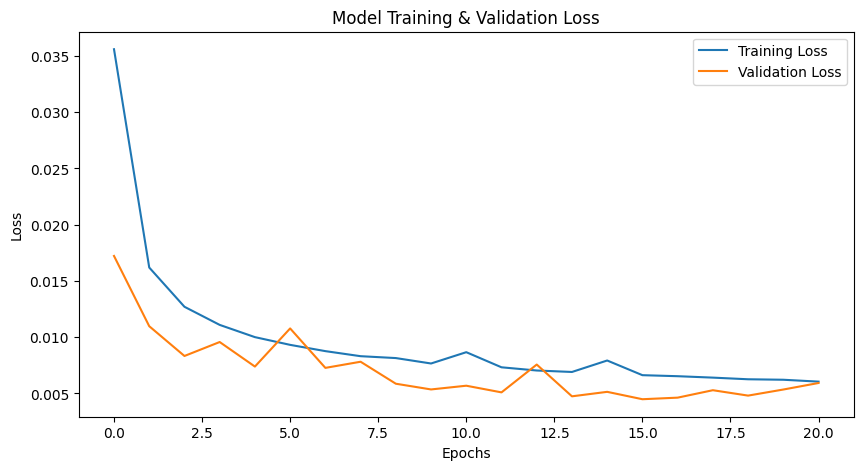

In [3]:
if __name__ == "__main__":
    model, history, scaler = main()

## CARE Score Implementation

In [22]:
## AnomalyEvent
class AnomalyEvent:
    """Classe représentant un événement d'anomalie avec ses caractéristiques temporelles et prédictions."""

    def __init__(self, start_idx: int, end_idx: int, timestamps: List, predictions: List[int], ground_truth: List[int]):
        """
        Initialise un événement d'anomalie.

        Args:
            start_idx: Indice de début de l'événement
            end_idx: Indice de fin de l'événement
            timestamps: Liste des horodatages de l'événement
            predictions: Liste des prédictions (0 ou 1) pour chaque horodatage
            ground_truth: Liste des vérités terrain (0 ou 1) pour chaque horodatage
        """
        self.start_idx = start_idx
        self.end_idx = end_idx
        self.timestamps = timestamps
        self.predictions = predictions
        self.ground_truth = ground_truth
        self.length = end_idx - start_idx + 1

    def is_detected(self) -> bool:
        """Vérifie si l'événement est détecté (au moins une prédiction positive)."""
        return 1 in self.predictions



##EventDetector
class EventDetector:
    """Classe utilitaire pour détecter des événements d'anomalie dans une série temporelle."""

    @staticmethod
    def detect_events(df: pd.DataFrame, status_column: str = 'status_id',
                      normal_value: str = 'normal', predictions_column: str = 'anomaly',
                      time_column: str = 'timestamp', min_gap: int = 3) -> List[AnomalyEvent]:
        """
        Détecte des événements d'anomalie dans une série temporelle.

        Args:
            df: DataFrame contenant les données
            status_column: Nom de la colonne contenant le statut (normal ou anormal)
            normal_value: Valeur indiquant un comportement normal
            predictions_column: Nom de la colonne contenant les prédictions d'anomalie
            time_column: Nom de la colonne contenant les horodatages
            min_gap: Écart minimal entre deux événements distincts

        Returns:
            Liste des événements d'anomalie détectés
        """
        # Convertir le statut en valeurs binaires (0 pour normal, 1 pour anormal)
        df_binary = df.copy()
        df_binary['status_binary'] = (df_binary[status_column] != normal_value).astype(int)

        # Identifier les séquences d'anomalies (statut anormal consécutif)
        status_changes = df_binary['status_binary'].diff().fillna(0).ne(0).cumsum()

        events = []
        current_event = None
        previous_end = -min_gap - 1

        # Parcourir chaque groupe d'indices avec le même statut
        for group_id, indices in df_binary.groupby(status_changes).groups.items():
            if len(indices) == 0:
                continue

            start_idx = indices[0]
            end_idx = indices[-1]

            # Ne traiter que les groupes avec des anomalies (statut anormal)
            if df_binary.loc[start_idx, 'status_binary'] == 1:
                # Si l'écart avec l'événement précédent est trop petit, fusionner les événements
                if start_idx - previous_end <= min_gap:
                    # Étendre l'événement actuel
                    if current_event is not None:
                        current_event.end_idx = end_idx
                        current_event.timestamps.extend(df_binary.loc[previous_end+1:end_idx, time_column].tolist())
                        current_event.predictions.extend(df_binary.loc[previous_end+1:end_idx, predictions_column].tolist())
                        current_event.ground_truth.extend(df_binary.loc[previous_end+1:end_idx, 'status_binary'].tolist())
                        current_event.length = current_event.end_idx - current_event.start_idx + 1
                else:
                    # Créer un nouvel événement
                    timestamps = df_binary.loc[start_idx:end_idx, time_column].tolist()
                    predictions = df_binary.loc[start_idx:end_idx, predictions_column].astype(int).tolist()
                    ground_truth = df_binary.loc[start_idx:end_idx, 'status_binary'].tolist()

                    current_event = AnomalyEvent(start_idx, end_idx, timestamps, predictions, ground_truth)
                    events.append(current_event)

                previous_end = end_idx

        return events



## Coverage
class Coverage:
    """
    Calcule le score de Coverage pour un modèle de détection d'anomalies.
    Le score de Coverage est basé sur le F-score et mesure la performance
    de classification sur des données contenant des anomalies.
    """

    def __init__(self, beta: float = 0.5):
        """
        Initialise la classe Coverage.

        Args:
            beta: Paramètre beta pour le calcul du F-score (valeur par défaut: 0.5)
                 Une valeur inférieure à 1 donne plus de poids à la précision qu'au rappel,
                 ce qui pénalise les faux positifs.
        """
        self.beta = beta

    def filter_prediction_time_frame(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Filtre le DataFrame pour ne conserver que les points de données avec des anomalies.

        Args:
            df: DataFrame contenant les données, incluant une colonne 'status_id'

        Returns:
            DataFrame filtré ne contenant que les lignes où 'status_id' est 'not normal'
        """
        filtered_df = df[df['status_id'] == 'not normal']
        return filtered_df

    def calculate_coverage_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> float:
        """
        Calcule le score de Coverage selon la formule théorique Fβ.
        Version optimisée avec vérification des dimensions et debug intégré.
        """
        # Création du masque temporel pour les anomalies réelles
        anomaly_mask = (df['status_id'] == 'not normal').values

        # Vérification de l'alignement des données
        if len(df) != len(anomaly_results):
            raise ValueError("Les DataFrames df et anomaly_results doivent avoir la même longueur")

        # Extraction des prédictions alignées avec le DataFrame original
        predictions = anomaly_results['anomaly'].astype(int).values

        # Calcul direct des composantes de la formule Fβ
        tp = np.sum(anomaly_mask & (predictions == 1))  # Vrais positifs
        fn = np.sum(anomaly_mask & (predictions == 0))  # Faux négatifs
        fp = np.sum(~anomaly_mask & (predictions == 1)) # Faux positifs

        # Calcul du dénominateur avec sécurité numérique
        denominator = (1 + self.beta**2) * tp + self.beta**2 * fn + fp
        if denominator <= 1e-9:
            return 0.0

        # Application de la formule théorique
        coverage_score = ((1 + self.beta**2) * tp) / denominator

        # Debug: Affichage des métriques intermédiaires
        print(f"[Coverage Debug] TP={tp}, FN={fn}, FP={fp}, Score={coverage_score:.4f}")

        return coverage_score

    def visualize_coverage(self, df: pd.DataFrame, anomaly_results: pd.DataFrame,
                         time_column: str = 'time_stamp') -> None:
        """
        Visualise le score de Coverage à travers le temps.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies
            time_column: Nom de la colonne contenant les horodatages
        """
        filtered_df = self.filter_prediction_time_frame(df)

        if filtered_df.empty:
            print("Pas de données disponibles pour la visualisation du Coverage.")
            return

        # Fusionner les données filtrées avec les prédictions
        merged_data = filtered_df.copy()
        merged_data['prediction'] = anomaly_results.loc[filtered_df.index, 'anomaly'].astype(int)

        # Calculer les TP, FN, FP, TN
        merged_data['TP'] = (merged_data['prediction'] == 1).astype(int)
        merged_data['FN'] = (merged_data['prediction'] == 0).astype(int)

        # Trier par horodatage
        merged_data.sort_values(time_column, inplace=True)

        # Créer le graphique
        plt.figure(figsize=(14, 6))

        # Tracer les TP et FN
        plt.scatter(merged_data[time_column], merged_data['TP'],
                  label='Anomalies détectées (TP)', color='green', alpha=0.7)
        plt.scatter(merged_data[time_column], merged_data['FN'],
                  label='Anomalies manquées (FN)', color='red', alpha=0.7)

        plt.title('Performance de Détection des Anomalies (Coverage)')
        plt.xlabel('Temps')
        plt.ylabel('Détection')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()




##Accuracy
class Accuracy:
    """
    Calcule le score d'Accuracy pour un modèle de détection d'anomalies.
    Le score d'Accuracy mesure la performance sur des données ne contenant
    que des comportements normaux, en se concentrant sur les vrais négatifs.
    """

    def filter_prediction_time_frame(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Filtre le DataFrame pour ne conserver que les points de données normaux.

        Args:
            df: DataFrame contenant les données, incluant une colonne 'status_id'

        Returns:
            DataFrame filtré ne contenant que les lignes où 'status_id' est 'normal'
        """
        filtered_df = df[df['status_id'] == 'normal']
        return filtered_df

    def calculate_accuracy_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> float:
        """
        Calcule le score d'Accuracy pour le modèle de détection d'anomalies.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies

        Returns:
            Score d'Accuracy calculé
        """

        if not df.index.equals(anomaly_results.index):
            print("Erreur: Les index des DataFrames ne correspondent pas.")

        # Créer un masque booléen pour les points normaux
        normal_mask = (df['status_id'] == 'normal').values
        # Récupérer les prédictions pour tous les points
        all_predictions = anomaly_results['anomaly'].astype(int).values
        # Calcul direct des TN et FP
        tn = np.sum((normal_mask) & (all_predictions == 0))
        fp = np.sum((normal_mask) & (all_predictions == 1))

        # Debug: Afficher les comptages
        print(f"[Accuracy Debug] TN={tn}, FP={fp}")

        # Calcul du score avec gestion des cas extrêmes
        denominator = tn + fp
        if denominator == 0:
            print("Avertissement: Aucun point normal détecté dans les prédictions")
            return 0.0
        accuracy_score = tn / denominator
        return accuracy_score

    def visualize_accuracy(self, df: pd.DataFrame, anomaly_results: pd.DataFrame,
                         time_column: str = 'time_stamp') -> None:
        """
        Visualise le score d'Accuracy à travers le temps.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies
            time_column: Nom de la colonne contenant les horodatages
        """
        filtered_df = self.filter_prediction_time_frame(df)

        if filtered_df.empty:
            print("Pas de données disponibles pour la visualisation de l'Accuracy.")
            return

        # Fusionner les données filtrées avec les prédictions
        merged_data = filtered_df.copy()
        merged_data['prediction'] = anomaly_results.loc[filtered_df.index, 'anomaly'].astype(int)

        # Calculer les TN et FP
        merged_data['TN'] = (merged_data['prediction'] == 0).astype(int)
        merged_data['FP'] = (merged_data['prediction'] == 1).astype(int)

        # Trier par horodatage
        merged_data.sort_values(time_column, inplace=True)

        # Créer le graphique
        plt.figure(figsize=(14, 6))

        # Tracer les TN et FP
        plt.scatter(merged_data[time_column], merged_data['TN'],
                  label='Comportements normaux correctement identifiés (TN)', color='blue', alpha=0.7)
        plt.scatter(merged_data[time_column], merged_data['FP'],
                  label='Fausses alarmes (FP)', color='orange', alpha=0.7)

        plt.title('Performance sur les Comportements Normaux (Accuracy)')
        plt.xlabel('Temps')
        plt.ylabel('Détection')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()



##Reliability
class Reliability:
    """
    Calcule le score de Reliability pour un modèle de détection d'anomalies.
    Le score de Reliability prend en compte les fausses alarmes sur une base
    d'événements en utilisant un algorithme de criticité.
    """

    def __init__(self, beta: float = 0.5, threshold: int = 72):
        """
        Initialise la classe Reliability.

        Args:
            beta: Paramètre beta pour le calcul du F-score (valeur par défaut: 0.5)
            threshold: Seuil de criticité pour la classification des événements (valeur par défaut: 72)
                      Ce seuil correspond à 12 heures d'anomalies consécutives (avec des mesures toutes les 10 minutes)
        """
        self.beta = beta
        self.threshold = threshold

    def _calculate_criticality(self, status_info: np.ndarray, predictions: np.ndarray) -> List[int]:
        """
        Calcule la criticité pour chaque point temporel.

        Args:
            status_info: Tableau représentant le statut du système (0 pour anormal, 1 pour normal)
            predictions: Tableau représentant les prédictions d'anomalies (0 pour normal, 1 pour anomalie)

        Returns:
            Liste des valeurs de criticité
        """
        # Appliquer l'algorithme de criticité comme défini dans l'image
        crit = [0]

        for i in range(1, len(status_info)):
            if status_info[i] == 0:  # Statut anormal
                if predictions[i] == 1:  # Anomalie prédite
                    crit.append(crit[i-1] + 1)  # Incrémenter la criticité
                else:  # Pas d'anomalie prédite
                    crit.append(max(crit[i-1] - 1, 0))  # Décrémenter la criticité, min 0
            else:  # Statut normal
                crit.append(crit[i-1])  # Maintenir la criticité

        return crit

    def calculate_reliability_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> float:
        """
        Calcule le score de Reliability pour le modèle de détection d'anomalies.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies

        Returns:
            Score de Reliability calculé
        """
        # Convertir le statut en valeurs binaires (1 pour normal, 0 pour anormal)
        status_info = df['status_id'].map({'normal': 1, 'not normal': 0}).values

        # Obtenir les prédictions
        predictions = anomaly_results['anomaly'].astype(int).values
        # Calculer la criticité pour chaque point temporel
        criticality = self._calculate_criticality(status_info, predictions)
        # Déterminer si un événement d'anomalie est détecté (criticité max > seuil)
        max_criticality = max(criticality) if criticality else 0
        event_detected = 1 if max_criticality > self.threshold else 0
        # Déterminer si un événement d'anomalie réel existe dans les données
        real_event = 1 if np.any(status_info == 0) else 0
        # Calculer les métriques pour le F-score au niveau des événements
        tp = 1 if (real_event == 1 and event_detected == 1) else 0
        fn = 1 if (real_event == 1 and event_detected == 0) else 0
        fp = 1 if (real_event == 0 and event_detected == 1) else 0

        # Éviter la division par zéro
        denominator = (1 + self.beta**2) * tp + self.beta**2 * fn + fp
        if denominator == 0:
            return 0.0

        # Calculer le F-score
        reliability_score = (1 + self.beta**2) * tp / denominator

        # Debug: afficher les métriques
        print(f"[Reliability] Max Criticality: {max_criticality}, Threshold: {self.threshold}")
        print(f"[Reliability] Event Detected: {event_detected}, Real Event: {real_event}")
        print(f"[Reliability] TP: {tp}, FN: {fn}, FP: {fp}, Score: {reliability_score:.4f}")

        return reliability_score

    def visualize_criticality(self, df: pd.DataFrame, anomaly_results: pd.DataFrame,
                           time_column: str = 'time_stamp') -> None:
        """
        Visualise la criticité et les événements détectés.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies
            time_column: Nom de la colonne contenant les horodatages
        """
        # Convertir le statut en valeurs binaires (1 pour normal, 0 pour anormal)
        status_info = df['status_id'].map({'normal': 1, 'not normal': 0}).values

        # Obtenir les prédictions
        predictions = anomaly_results['anomaly'].astype(int).values

        # Calculer la criticité pour chaque point temporel
        criticality = self._calculate_criticality(status_info, predictions)

        # Fusionner les données avec la criticité
        merged_data = df.copy()
        merged_data['criticality'] = criticality
        merged_data['prediction'] = predictions
        merged_data['status_binary'] = status_info

        # Trier par horodatage
        merged_data.sort_values(time_column, inplace=True)

        # Créer le graphique
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

        # Tracer la criticité
        ax1.plot(merged_data[time_column], merged_data['criticality'], color='purple', label='Criticité')
        ax1.axhline(y=self.threshold, color='r', linestyle='--', label=f'Seuil ({self.threshold})')
        ax1.set_title('Criticité au Fil du Temps')
        ax1.set_ylabel('Criticité')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # Tracer les statuts et prédictions
        ax2.scatter(merged_data[time_column], merged_data['status_binary'],
                  label='Statut Réel (0=anormal, 1=normal)', color='blue', alpha=0.5)
        ax2.scatter(merged_data[time_column], merged_data['prediction'],
                  label='Prédiction (1=anomalie)', color='red', alpha=0.5)
        ax2.set_title('Statuts et Prédictions')
        ax2.set_xlabel('Temps')
        ax2.set_ylabel('État')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


## Earliness
class Earliness:
    """
    Calcule le score d'Earliness pour un modèle de détection d'anomalies.
    Le score d'Earliness mesure la rapidité avec laquelle le modèle détecte
    les anomalies, en donnant plus de poids aux détections précoces.
    """
    def __init__(self):
        # Initialize event detector
        self.event_detector = EventDetector()

    def _calculate_weights(self, event_length: int) -> np.ndarray:
        """
        Calcule les poids pour un événement d'anomalie en fonction de sa longueur.

        Args:
            event_length: Longueur de l'événement d'anomalie

        Returns:
            Tableau des poids pour chaque point temporel de l'événement
        """
        weights = np.ones(event_length)

        # Appliquer la fonction de pondération linéaire décroissante
        # comme décrit dans l'image: poids décroissants de 1 à 0 sur toute la longueur
        weights = np.linspace(1.0, 0.0, event_length)

        return weights

    def _calculate_weighted_score(self, event: AnomalyEvent) -> float:
            """
            Calcule le score pondéré (WS) pour un événement d'anomalie.

            Args:
                event: Objet AnomalyEvent contenant les informations sur l'événement

            Returns:
                Score pondéré calculé
            """
            if not event.is_detected():
                return 0.0

            # Correction : Utiliser la longueur réelle de event.predictions
            # Obtenir les prédictions binaires (1 pour anomalie, 0 pour normal)
            predictions = np.array(event.predictions).astype(int)
            # Calculer les poids selon la position relative dans l'événement
            weights = self._calculate_weights(len(predictions))
            # Calculer le numérateur et dénominateur séparément pour le debug
            numerator = np.sum(weights * predictions)
            denominator = np.sum(weights)

            # Éviter division par zéro
            if denominator == 0:
                return 0.0

            # Appliquer la formule du WS
            weighted_score = numerator / denominator

            # # Debug: afficher les composantes du calcul
            # print(f"[Earliness Debug] Événement longueur={len(predictions)}, "
            #     f"Détections={np.sum(predictions)}, Score={weighted_score:.4f}")

            return weighted_score

    def calculate_earliness_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> float:
        """
        Calcule le score d'Earliness pour le modèle de détection d'anomalies.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies

        Returns:
            Score d'Earliness calculé
        """
        # Détecter les événements d'anomalie
        combined_df = df.copy()
        combined_df['anomaly'] = anomaly_results['anomaly']
        anomaly_events = self.event_detector.detect_events(combined_df, predictions_column='anomaly')

        if not anomaly_events:
            print("Attention: Aucun événement d'anomalie détecté pour le calcul d'Earliness.")
            return 0.0

        # Calculer le score pondéré pour chaque événement
        weighted_scores = [self._calculate_weighted_score(event) for event in anomaly_events]

        # Calculer le score d'Earliness global (moyenne des scores pondérés)
        earliness_score = np.mean(weighted_scores) if weighted_scores else 0.0

        return earliness_score

    def visualize_earliness(self, df: pd.DataFrame, anomaly_results: pd.DataFrame,
                          time_column: str = 'time_stamp') -> None:
        """
        Visualise le score d'Earliness pour chaque événement d'anomalie.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies
            time_column: Nom de la colonne contenant les horodatages
        """
        # Détecter les événements d'anomalie
        event_detector = EventDetector()
        anomaly_events = event_detector.detect_events(df, predictions_column='anomaly')

        if not anomaly_events:
            print("Pas d'événements d'anomalie à visualiser.")
            return

        # Calculer les scores pondérés
        scores = [self._calculate_weighted_score(event) for event in anomaly_events]

        # Extraire les informations des événements pour la visualisation
        event_ids = list(range(len(anomaly_events)))
        event_lengths = [event.length for event in anomaly_events]

        # Créer un graphique à barres pour les scores d'Earliness par événement
        plt.figure(figsize=(12, 6))
        bars = plt.bar(event_ids, scores, alpha=0.7)

        # Ajouter les longueurs d'événement comme étiquettes
        for i, (bar, length) in enumerate(zip(bars, event_lengths)):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                   f'Longueur: {length}', ha='center', va='bottom', rotation=0, fontsize=8)

        plt.title('Score d\'Earliness par Événement d\'Anomalie')
        plt.xlabel('ID de l\'Événement')
        plt.ylabel('Score d\'Earliness (WS)')
        plt.ylim(0, 1.1)
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

        # Visualiser un exemple d'événement avec ses poids
        if anomaly_events:
            example_event = max(anomaly_events, key=lambda e: e.length)  # Prendre l'événement le plus long
            weights = self._calculate_weights(example_event.length)

            # Créer un graphique pour les poids
            plt.figure(figsize=(10, 5))
            plt.plot(range(example_event.length), weights, 'b-', linewidth=2)
            plt.title('Fonction de Pondération pour un Événement d\'Anomalie')
            plt.xlabel('Position Temporelle dans l\'Événement')
            plt.ylabel('Poids')
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()


## CARE score
class CAREScore:
    """
    Calcule le score CARE pour un modèle de détection d'anomalies.
    Le score CARE combine les quatre métriques: Coverage, Accuracy, Reliability et Earliness.
    """

    def __init__(self, omega1: float = 1.0, omega2: float = 1.0, omega3: float = 1.0, omega4: float = 2.0):
        """
        Initialise la classe CAREScore.

        Args:
            omega1: Poids pour le score Coverage (valeur par défaut: 1.0)
            omega2: Poids pour le score Accuracy (valeur par défaut: 1.0)
            omega3: Poids pour le score Reliability (valeur par défaut: 1.0)
            omega4: Poids pour le score Earliness (valeur par défaut: 2.0)
        """
        self.omega1 = omega1
        self.omega2 = omega2
        self.omega3 = omega3
        self.omega4 = omega4

        # Initialiser les métriques individuelles
        self.coverage = Coverage(beta=0.5)
        self.accuracy = Accuracy()
        self.reliability = Reliability(beta=0.5, threshold=72)
        self.earliness = Earliness()

    def _calculate_weighted_average(self, scores: Dict[str, float]) -> float:
        """
        Calcule la moyenne pondérée des scores individuels.

        Args:
            scores: Dictionnaire des scores individuels

        Returns:
            Moyenne pondérée calculée
        """
        weights_sum = self.omega1 + self.omega2 + self.omega3 + self.omega4

        weighted_sum = (
            self.omega1 * scores['coverage'] +
            self.omega2 * scores['earliness'] +
            self.omega3 * scores['reliability'] +
            self.omega4 * scores['accuracy']
        )

        return weighted_sum / weights_sum

    def calculate_care_score(self, df: pd.DataFrame, anomaly_results: pd.DataFrame) -> Dict[str, float]:
        """
        Calcule le score CARE global et les sous-scores.

        Args:
            df: DataFrame original contenant les données
            anomaly_results: DataFrame contenant les prédictions d'anomalies

        Returns:
            Dictionnaire contenant le score CARE et les sous-scores
        """
        # Calculer les scores individuels
        coverage_score = self.coverage.calculate_coverage_score(df, anomaly_results)
        accuracy_score = self.accuracy.calculate_accuracy_score(df, anomaly_results)
        reliability_score = self.reliability.calculate_reliability_score(df, anomaly_results)
        earliness_score = self.earliness.calculate_earliness_score(df, anomaly_results)

        scores = {
            'coverage': coverage_score,
            'accuracy': accuracy_score,
            'reliability': reliability_score,
            'earliness': earliness_score
        }

        # Vérifier s'il y a des anomalies détectées
        any_anomalies_detected = anomaly_results['anomaly'].sum() > 0

        # Calculer le score CARE final selon les conditions
        if not any_anomalies_detected:
            care_score = 0.0
        elif accuracy_score < 0.5:
            care_score = accuracy_score
        else:
            care_score = self._calculate_weighted_average(scores)

        # Ajouter le score CARE au dictionnaire des résultats
        scores['care'] = care_score

        return scores

    def visualize_care_score(self, scores: Dict[str, float]) -> None:
        """
        Visualise le score CARE et ses composantes.

        Args:
            scores: Dictionnaire contenant le score CARE et les sous-scores
        """
        # Créer des graphiques pour visualiser les scores
        labels = ['Coverage', 'Accuracy', 'Reliability', 'Earliness', 'CARE']
        values = [scores['coverage'], scores['accuracy'], scores['reliability'],
                scores['earliness'], scores['care']]
        colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

        # Graphique à barres des scores
        plt.figure(figsize=(12, 6))
        bars = plt.bar(labels, values, color=colors, alpha=0.8)

        # Ajouter les valeurs au-dessus des barres
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                   f'{height:.2f}', ha='center', va='bottom')

        plt.title('Score CARE et les sub-scores')
        plt.ylabel('Score')
        plt.ylim(0, 1.1)
        plt.grid(True, axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()

In [23]:
def care_score_processor(df_test, anomaly_column):
      new_df = df_test.copy()

      # Rename 'status_type_id' to 'status_id'
      new_df.rename(columns={'status_type_id': 'status_id'}, inplace=True)
      new_df.rename(columns={'time_stamp': 'timestamp'}, inplace=True)

      # Rename anomaly column to 'anomaly'
      new_df.rename(columns={anomaly_column: 'anomaly'}, inplace=True)

      # Process the 'anomaly' column: -1 to 0, 0 to 0, 1 to 1 (in integer form)
      new_df['anomaly'] = new_df['anomaly'].apply(lambda x: 0 if x == -1 else (1 if x == 1 else x))

      # Process the 'status_id' column: 0, 2 to 0, rest to 1
      new_df['status_id'] = new_df['status_id'].apply(lambda x: 'normal' if x in [0, 2] else 'not normal')

      return new_df

## Evaluation Pipeline

In [4]:
from tensorflow.keras.models import load_model
#model.save('model_CNN_LSTM.keras')
# Load the autoencoder model
model = load_model('model_CNN_LSTM.keras')

In [15]:
df1 = pd.read_parquet("/content/partie1.parquet")
df2 = pd.read_parquet("/content/partie2.parquet")
df = pd.concat([df1, df2], ignore_index=True)


feature_columns = ['sensor_50', 'wind_speed_3_avg', 'wind_speed_4_avg', 'sensor_45',
                       'power_30_avg', 'reactive_power_28_avg', 'reactive_power_27_avg',
                       'sensor_24_avg', 'sensor_18_avg', 'sensor_18_min', 'sensor_25_avg',
                       'sensor_52_min', 'sensor_23_avg', 'sensor_52_avg',
                       'sensor_44', 'sensor_51', 'sensor_48', 'sensor_5_max', 'power_29_avg']


normal_train_scaled, val_scaled, test_scaled, val_data, test_data, feature_columns, scaler = prepare_data(df,feature_columns)

In [19]:
# Set parameters
seq_length = 6
batch_size = 16
epochs = 30
encoding_dim = 16



# Calculate anomaly threshold from training data
print("\n📌 Calcul du seuil d'anomalie...")
train_errors_subset = calculate_reconstruction_errors(model, normal_train_scaled, seq_length)
threshold = np.mean(train_errors_subset) + 3 * np.std(train_errors_subset)
print(f"\n ✔ Seuil d'anomalie calculé : {threshold:.4f}")


📌 Calcul du seuil d'anomalie...
21490/21490 ━━━━━━━━━━━━━━━━━━━━ 101s 5ms/step

 ✔ Seuil d'anomalie calculé : 0.0730


In [20]:
# Detect anomalies in test data
print("Detecting anomalies...")
test_errors = calculate_reconstruction_errors(model, test_scaled, seq_length)

# Map errors back to original data points
anomaly_scores = np.zeros(len(test_scaled))
for i in range(len(test_errors)):
    idx = i + seq_length - 1
    if idx < len(anomaly_scores):
        anomaly_scores[idx] = test_errors[i]


# For the first seq_length-1 points, copy the first available score
anomaly_scores[:seq_length-1] = anomaly_scores[seq_length-1]

Detecting anomalies...
1581/1581 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step


In [21]:
# Add results to test dataframe
test_data['anomaly_score'] = anomaly_scores
test_data['anomaly'] = (anomaly_scores > threshold).astype(int)
test_data.rename(columns={'time_stamp': 'timestamp'}, inplace=True)


# Evaluate model
print("\n📌 Évaluation du modèle...")
true_labels = ~test_data['status_type_id'].isin([0, 2])
predicted_labels = test_data['anomaly']
predicted_labels = pd.DataFrame(predicted_labels)


📌 Évaluation du modèle...


<ipython-input-21-2fc16f0120e9>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['anomaly_score'] = anomaly_scores
<ipython-input-21-2fc16f0120e9>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['anomaly'] = (anomaly_scores > threshold).astype(int)
<ipython-input-21-2fc16f0120e9>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returni

In [24]:
# Analyse des résultats avec care_score_processor
df_LSTM_care_score = care_score_processor(test_data, 'anomaly')
df_LSTM_care_score.groupby(['anomaly', 'status_id']).size()

anomaly_results = pd.DataFrame({
    'anomaly': df_LSTM_care_score['anomaly']
}, index=df_LSTM_care_score.index)

care_calculator = CAREScore(omega1=1.0, omega2=1.0, omega3=1.0, omega4=2.0)
scores = care_calculator.calculate_care_score(df_LSTM_care_score, anomaly_results)

[Coverage Debug] TP=155, FN=11340, FP=243, Score=0.0592
[Accuracy Debug] TN=38855, FP=243
[Reliability] Max Criticality: 16, Threshold: 72
[Reliability] Event Detected: 0, Real Event: 1
[Reliability] TP: 0, FN: 1, FP: 0, Score: 0.0000


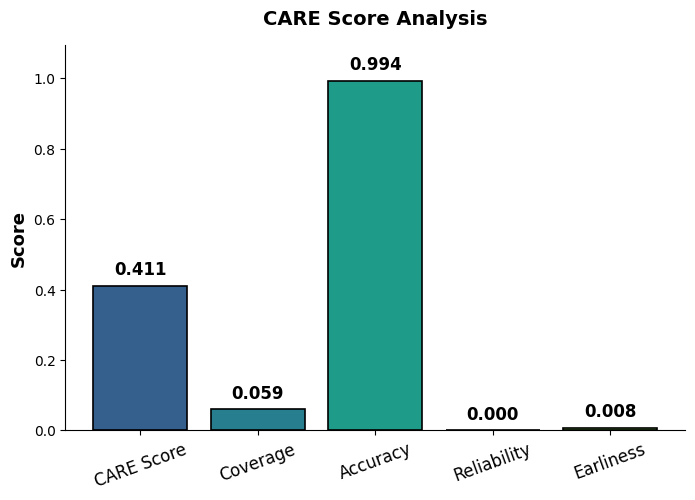

In [26]:
# Extract scores
data = {
    "CARE Score": scores['care'],
    "Coverage": scores['coverage'],
    "Accuracy": scores['accuracy'],
    "Reliability": scores['reliability'],
    "Earliness": scores['earliness']
}

# Create figure and axis
fig, ax = plt.subplots(figsize=(8, 5))

# Generate colors using Viridis colormap
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(data)))

# Create bar chart
bars = ax.bar(data.keys(), data.values(), color=colors, edgecolor="black", linewidth=1.2)

# Add value labels on top of bars
for bar, value in zip(bars, data.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f'{value:.3f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# Customizations
ax.set_ylabel("Score", fontsize=13, fontweight='bold')
ax.set_title("CARE Score Analysis", fontsize=14, fontweight='bold', pad=15)
ax.set_ylim(0, max(data.values()) + 0.1)  # Add some space above bars
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Rotate x-axis labels if needed
plt.xticks(rotation=20, fontsize=12)

# Show plot
plt.show()